# SIMSOPT Stage-2 Coils

## What you will learn
Why plasma-boundary optimization is incomplete until coils reproduce the target field with acceptable complexity.

## Codes used
SIMSOPT in research mode; synthetic coil curves and normal-field-error maps by default.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
Initial/final coil plots, `04_bdotn_before_after.png`, and `04_coil_tradeoff.png`.

## What this teaches

The object is the coil contract: curves whose normal field error and complexity must be judged together.

## What this does not prove

It does not prove a production SIMSOPT optimization or manufacturable coil set.

## Literature anchor

Stage-2 coil design is where a beautiful boundary becomes an engineering contract. SIMSOPT provides the object model for curves, Biot-Savart fields, VMEC coupling, and least-squares objectives; single-stage work goes further by letting plasma and coil variables move together under a quadratic-flux penalty.

Reading: Landreman et al., *JOSS* 6, 3525 (2021), https://joss.theoj.org/papers/10.21105/joss.03525; Jorge et al., *Plasma Phys. Control. Fusion* 65, 074003 (2023), https://arxiv.org/abs/2302.10622.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.coil_helpers import coil_curves, normal_field_error, tradeoff_table
from sos2026.vmec_helpers import synthetic_surface
from sos2026.plotting import PALETTE, savefig, caption, frame_3d_axes

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
tradeoff = tradeoff_table()
tradeoff

,weight_length,quadratic_flux,coil_length,max_curvature
0,0.02,1.00,1.32,1.55
1,0.05,0.58,1.20,1.38
2,0.10,0.36,1.10,1.24
3,0.20,0.31,1.02,1.18
4,0.40,0.44,0.96,1.16


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

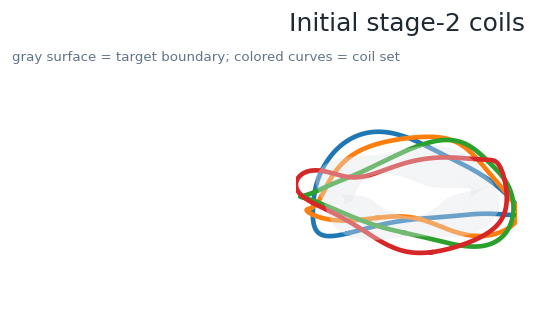

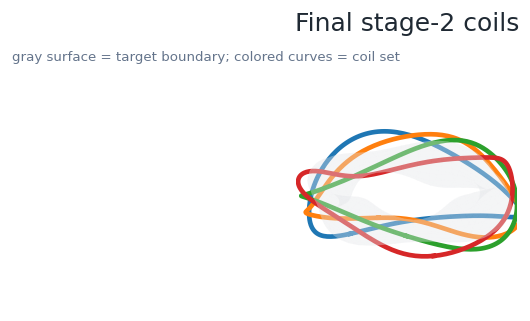

Caption: these coils are cached geometry for teaching the stage-2 inverse problem.


In [7]:
surface = synthetic_surface("hsx", ntheta=36, nphi=64)
for stage, name in [("initial", "04_initial_coils.png"), ("final", "04_final_coils.png")]:
    fig = plt.figure(figsize=(7.0, 3.9))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(surface["x"], surface["y"], surface["z"], color="#e5e7eb", linewidth=0, alpha=0.22, shade=False, rstride=2, cstride=2)
    for curve in coil_curves(stage):
        ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], lw=2.8)
    frame_3d_axes(ax, f"{stage.capitalize()} stage-2 coils", elev=24, azim=32, zoom=1.95, rect=(-0.07, -0.18, 1.18, 1.22))
    ax.figure.text(0.03, 0.86, "gray surface = target boundary; colored curves = coil set", fontsize=8, color=PALETTE["gray"])
    savefig(fig, name)
    plt.show()
print("Caption: these coils are cached geometry for teaching the stage-2 inverse problem.")

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

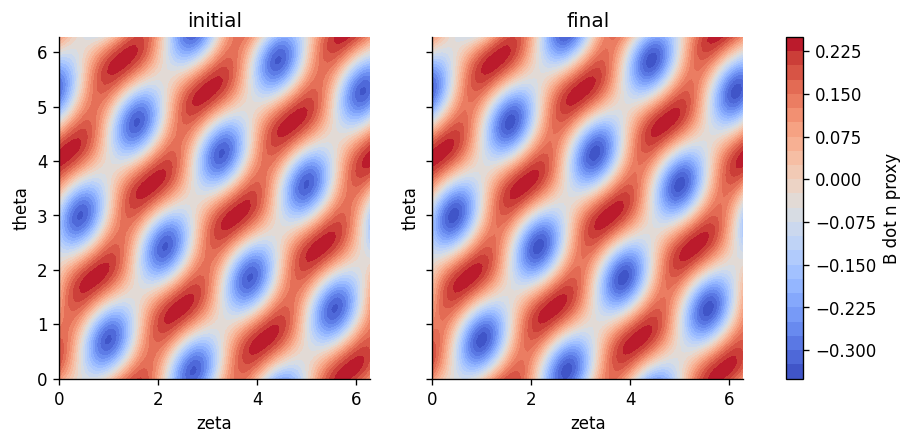

Caption: stage-2 optimization tries to reduce normal field error without producing unbuildable coils.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7), sharex=True, sharey=True)
for ax, stage in zip(axes, ["initial", "final"]):
    theta, zeta, err = normal_field_error(stage)
    im = ax.contourf(zeta, theta, err, levels=24, cmap="coolwarm")
    ax.set_title(stage)
    ax.set_xlabel("zeta")
    ax.set_ylabel("theta")
fig.colorbar(im, ax=axes.ravel().tolist(), label="B dot n proxy")
fig.savefig(FIGURE_DIR / "04_bdotn_before_after.png", dpi=160, bbox_inches="tight")
plt.show()
print("Caption: stage-2 optimization tries to reduce normal field error without producing unbuildable coils.")

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

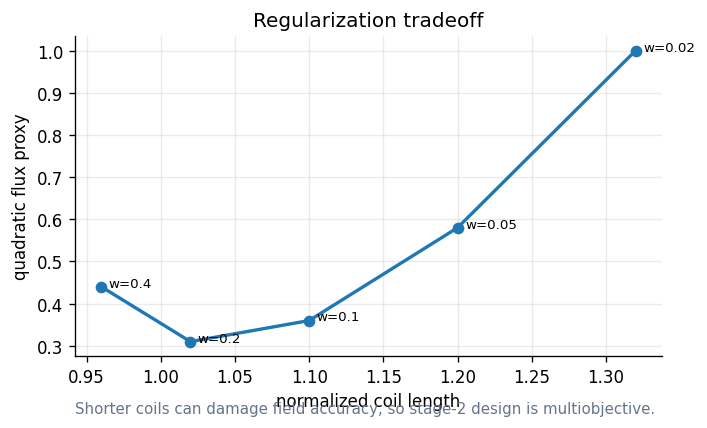

In [9]:
fig, ax = plt.subplots(figsize=(6.0, 3.7))
ax.plot(tradeoff["coil_length"], tradeoff["quadratic_flux"], marker="o", lw=2)
for _, row in tradeoff.iterrows():
    ax.text(row["coil_length"] + 0.005, row["quadratic_flux"], f"w={row['weight_length']}", fontsize=8)
ax.set_xlabel("normalized coil length")
ax.set_ylabel("quadratic flux proxy")
ax.set_title("Regularization tradeoff")
ax.grid(alpha=0.25)
caption(ax, "Shorter coils can damage field accuracy, so stage-2 design is multiobjective.")
savefig(fig, "04_coil_tradeoff.png")
plt.show()

## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    import simsopt
    print("SIMSOPT import OK:", getattr(simsopt, "__version__", "unknown"))
    print("Research path: load data/inputs/simsopt/input.LandremanPaul2021_QA")
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

,weight_length,quadratic_flux,coil_length,max_curvature,balanced_score
3,0.20,0.31,1.02,1.18,0.051923
4,0.40,0.44,0.96,1.16,0.103623
2,0.10,0.36,1.10,1.24,0.178103
1,0.05,0.58,1.20,1.38,0.494705
0,0.02,1.00,1.32,1.55,1.000000


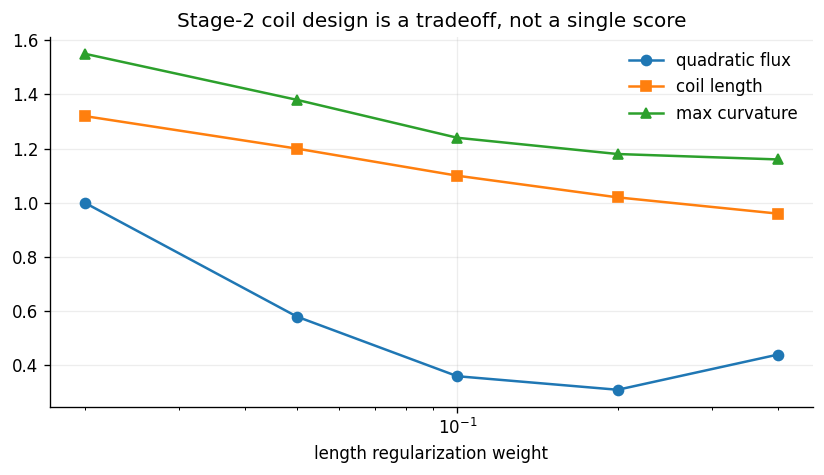

Caption: the selected coil set depends on how much field accuracy, length, and curvature are valued.


In [13]:
from sos2026.coil_helpers import tradeoff_table
table = tradeoff_table().copy()
for col in ["quadratic_flux", "coil_length", "max_curvature"]:
    table[col + "_scaled"] = (table[col] - table[col].min()) / (table[col].max() - table[col].min())
table["balanced_score"] = 0.55 * table["quadratic_flux_scaled"] + 0.25 * table["coil_length_scaled"] + 0.20 * table["max_curvature_scaled"]
display(table[["weight_length", "quadratic_flux", "coil_length", "max_curvature", "balanced_score"]].sort_values("balanced_score"))
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(table["weight_length"], table["quadratic_flux"], "o-", label="quadratic flux")
ax.plot(table["weight_length"], table["coil_length"], "s-", label="coil length")
ax.plot(table["weight_length"], table["max_curvature"], "^-", label="max curvature")
ax.set_xscale("log")
ax.set_xlabel("length regularization weight")
ax.set_title("Stage-2 coil design is a tradeoff, not a single score")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.show()
print("Caption: the selected coil set depends on how much field accuracy, length, and curvature are valued.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.